In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))
#test

In [2]:
from anthropmass.mass.massmain_module import *
from anthropmass.prediction_module import *
from anthropmass.mass.massmesh_module import *
from anthropmass.mass.measurements_heights_module import *
from anthropmass.mass.massurdf_module import *
import pandas as pd

This is just to get all columns

In [3]:
train=pd.read_csv('../data/processed/ANSURIInormalizedtrain.csv')
y_train=train.iloc[:,1:94].drop('weightkg',axis=1).drop('stature',axis=1)
variables = y_train.columns[:]

In [4]:
def make_a_man(weight, height, gender):
    df = make_predictions('xgboost',variables, weight, height, gender)
    main(df, weight, height)

RESULTS:
Total Estimated Weight (kg) (only with Volume model using 1000kg/m3): 79.3367681035973
Total Estimated Weight (kg) using regression model 84.17013560257122
Actual Weight (kg): 80
Estimated Height (m): 1.810859203338623
Actual Height (m): 1.8


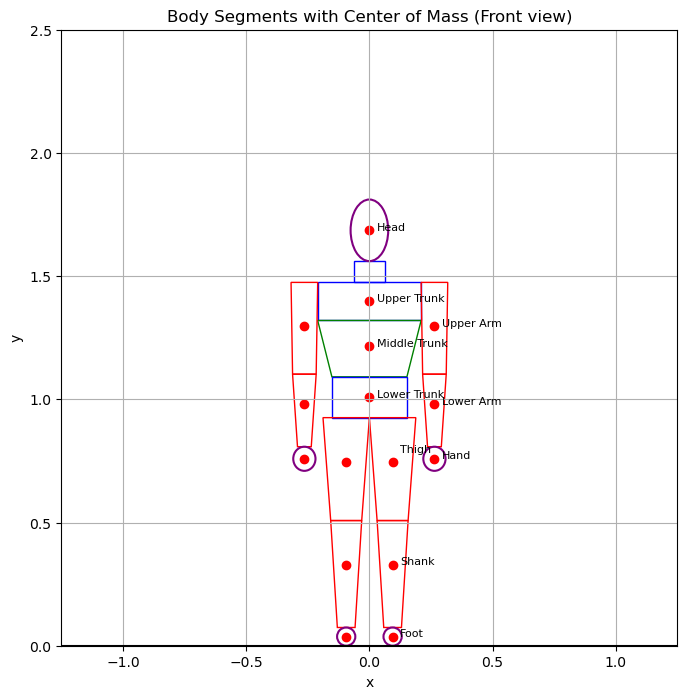

In [5]:
make_a_man(80,1800,1)

In [ ]:
def generate_urdf_files(weight: int, height: int, gender: int):
    # 1) get the *raw* ANSUR row back out of your prediction
    person = make_predictions('xgboost',variables, weight, height, gender)


    # 2) compute just once for the meshes
    meas = get_measurements(person, height)

    # 3) write all the .stl’s
    generate_all_meshes(meas, height)
    print("Done")
    # 4) write the .urdf from the *raw* row, so it can call get_measurements again
    create_urdf(person, height)


In [7]:
generate_urdf_files(80,1800,1)

✅ Meshes successfully saved to: c:\Users\theo4\OneDrive\Skrivbord\bsp_estimation\anthropmass\anthropmass\mass\model_output
✅ URDF file successfully generated at: c:\Users\theo4\OneDrive\Skrivbord\bsp_estimation\anthropmass\anthropmass\mass\model_output\simple_human.urdf
